# Hillstrom Action-Selection Winner's Curse

This notebook evaluates winner's curse corrections in the Hillstrom/MineThatData e-mail experiment. The firm chooses among **three actions** — `No E-Mail`, `Mens E-Mail`, `Womens E-Mail` — where doing nothing (`No E-Mail`) is itself a legitimate action, not just a control baseline. We estimate each action's mean spend per customer, select the action with the highest realized mean spend, and report the selected action's value. The winner's curse is the upward bias in that selected mean.

The correction estimators are imported **directly** from the repository (`winners_curse.ab_test`), so they are byte-for-byte the same methods used in the paper: no correction, standard bootstrap, m-out-of-n bootstrap, sample splitting, empirical Bayes, and hybrid selective inference. The m-out-of-n bootstrap uses `m = floor(N^0.90)` with the canonical `sqrt(m/N)` rescaling, matching the leaderboard paper. The split-validation section follows the leaderboard paper's half-sample logic: a selection half ranks the winning action and estimates each method's correction, an independent validation half evaluates the selected action's realized mean spend, and the residual is the mean reference bias minus the mean estimated bias.

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from winners_curse.ab_test import (
    select_higher_effect,
    bootstrap_correction_estimate,
    sample_splitting_estimate,
    empirical_bayes_estimate,
    selective_inference_estimate,
)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

DATA_PATH = Path("dataset/Kevin_Hillstrom_MineThatData_E-MailAnalytics_DataMiningChallenge_2008.03.20.csv")
if not DATA_PATH.exists():
    DATA_PATH = Path("../dataset/Kevin_Hillstrom_MineThatData_E-MailAnalytics_DataMiningChallenge_2008.03.20.csv")

OUTCOME = "spend"
# Three competing actions the firm can take. "No E-Mail" is a genuine action
# (do nothing), not a control baseline, so all three arms are candidates and the
# estimand is the selected action's mean spend per customer.
ACTIONS = ["No E-Mail", "Mens E-Mail", "Womens E-Mail"]
ARMS = ACTIONS  # alias kept for the EDA cells
ESTIMATOR_ORDER = [
    "No Correction",
    "Standard Bootstrap",
    "m-out-of-n Bootstrap",
    "Sample Splitting",
    "Empirical Bayes",
    "Hybrid Selective Inference",
]

# Runtime knobs. Increase these for a slower, lower Monte Carlo error run.
FULL_BOOTSTRAPS = 2_000
FULL_SAMPLE_SPLITS = 500
N_OUTER_SPLITS = 200
SPLIT_BOOTSTRAPS = 200
SPLIT_SAMPLE_SPLITS = 100
# The leaderboard WC paper uses m = floor(N^gamma) with gamma = 0.90; the src
# m-out-of-n estimator rescales each bootstrap gap by sqrt(m/N) internally.
MOON_POWER = 0.90
RANDOM_SEED = 20260627

## EDA

The experiment has three randomized arms. The analysis uses `spend` as dollars spent per assigned customer during the two-week post-campaign window. `visit` and `conversion` are diagnostic outcomes.

In [2]:
df = pd.read_csv(DATA_PATH)

audit = pd.DataFrame(
    {
        "rows": [len(df)],
        "columns": [df.shape[1]],
        "missing_cells": [int(df.isna().sum().sum())],
        "positive_spend_rows": [int((df[OUTCOME] > 0).sum())],
        "max_spend": [df[OUTCOME].max()],
    }
)
audit

,rows,columns,missing_cells,positive_spend_rows,max_spend
0,64000,12,0,578,499.0000


In [3]:
arm_summary = (
    df.groupby("segment", observed=True)
    .agg(
        rows=(OUTCOME, "size"),
        share=(OUTCOME, lambda values: values.size / len(df)),
        spend_mean=(OUTCOME, "mean"),
        spend_sd=(OUTCOME, "std"),
        positive_spend_rate=(OUTCOME, lambda values: (values > 0).mean()),
        visit_rate=("visit", "mean"),
        conversion_rate=("conversion", "mean"),
    )
    .loc[ARMS]
)
arm_summary

,rows,share,spend_mean,spend_sd,positive_spend_rate,visit_rate,conversion_rate
segment,,,,,,,
No E-Mail,21306,0.3329,0.6528,11.5882,0.0057,0.1062,0.0057
Mens E-Mail,21307,0.3329,1.4226,17.7542,0.0125,0.1828,0.0125
Womens E-Mail,21387,0.3342,1.0772,15.1161,0.0088,0.1514,0.0088


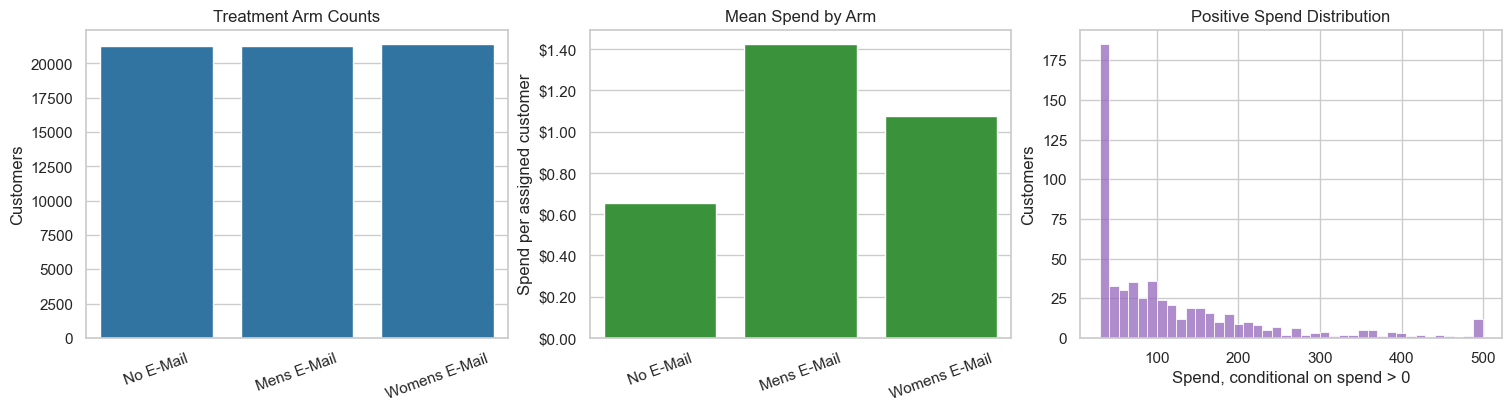

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)

sns.barplot(data=arm_summary.reset_index(), x="segment", y="rows", ax=axes[0], color="tab:blue")
axes[0].set_title("Treatment Arm Counts")
axes[0].set_xlabel("")
axes[0].set_ylabel("Customers")
axes[0].tick_params(axis="x", rotation=20)

sns.barplot(data=arm_summary.reset_index(), x="segment", y="spend_mean", ax=axes[1], color="tab:green")
axes[1].set_title("Mean Spend by Arm")
axes[1].set_xlabel("")
axes[1].set_ylabel("Spend per assigned customer")
axes[1].yaxis.set_major_formatter(lambda value, _: f"${value:0.2f}")
axes[1].tick_params(axis="x", rotation=20)

positive_spend = df.loc[df[OUTCOME] > 0, OUTCOME]
sns.histplot(positive_spend, bins=40, ax=axes[2], color="tab:purple")
axes[2].set_title("Positive Spend Distribution")
axes[2].set_xlabel("Spend, conditional on spend > 0")
axes[2].set_ylabel("Customers")

plt.show()

## Estimator Definitions

Every correction is the repository's own A/B-test estimator, imported directly from `winners_curse.ab_test`: `bootstrap_correction_estimate` (standard and `moon` / m-out-of-n variants), `sample_splitting_estimate`, `empirical_bayes_estimate`, and `selective_inference_estimate` (hybrid). This guarantees the notebook reproduces exactly the methods validated in the paper rather than re-deriving them.

The action-selection problem maps onto the src A/B interface with no reshaping: the three action arms are passed directly as the estimator `samples`, the optimizer `select_higher_effect` picks the arm with the highest mean spend, and each estimator returns the corrected **mean spend** of the selected action. There is no control subtraction — `No E-Mail` is one of the competing arms, so its mean spend competes on the same footing as the two e-mail campaigns.

For empirical Bayes we use the repository's normal-prior shrinkage (`prior="normal"`), which shrinks the three action means toward their common mean.

In [ ]:
def make_arm_arrays(data: pd.DataFrame) -> dict[str, np.ndarray]:
    """Return outcome arrays by action arm."""
    return {arm: data.loc[data["segment"] == arm, OUTCOME].to_numpy() for arm in ACTIONS}


def estimate_action_values(arms: dict[str, np.ndarray]) -> tuple[np.ndarray, np.ndarray]:
    """Estimate each action's mean spend and the sampling variance of that mean."""
    values = []
    variances = []
    for action in ACTIONS:
        arm = arms[action]
        values.append(arm.mean())
        variances.append(arm.var(ddof=1) / arm.size)
    return np.array(values), np.array(variances)


def selected_action(values: np.ndarray) -> tuple[int, str, float]:
    """Return selected action index, label, and its mean spend."""
    selected_idx = int(np.argmax(values))
    return selected_idx, ACTIONS[selected_idx], float(values[selected_idx])


# Stratified train/validation splitter for the outer audit (Section "Repeated
# Stratified Train/Validation Splits"). This is the paper's half-sample
# validation harness, *not* a correction method.
def split_arm_positions(arms: dict[str, np.ndarray], split_fraction: float, rng: np.random.Generator):
    """Create stratified positions for a first and second split within each arm."""
    first = {}
    second = {}
    for arm, values in arms.items():
        n_first = int(round(values.size * split_fraction))
        n_first = min(max(n_first, 2), values.size - 2)
        shuffled = rng.permutation(values.size)
        first[arm] = shuffled[:n_first]
        second[arm] = shuffled[n_first:]
    return first, second


def subset_arms(arms: dict[str, np.ndarray], positions: dict[str, np.ndarray]) -> dict[str, np.ndarray]:
    """Subset each action arm by positions."""
    return {arm: values[positions[arm]] for arm, values in arms.items()}


# ---------------------------------------------------------------------------
# Corrections: every method below is the repository's A/B-test estimator from
# ``winners_curse.ab_test`` applied to the three action arms.
#
# The src estimators (i) select the highest-MEAN-spend arm and (ii) return the
# corrected mean spend of that arm. The three action arms (No E-Mail, Mens
# E-Mail, Womens E-Mail) are passed directly as ``samples`` with no control
# subtraction: doing nothing is one of the competing actions.
# ---------------------------------------------------------------------------
OPTIMIZATION_PARAMS = {"optimizer": select_higher_effect, "params": {}}
RESPONSE_TYPE = "continuous"


def candidate_samples(arms: dict[str, np.ndarray]) -> list[np.ndarray]:
    """Per-customer spend for each action arm (the src ``samples``)."""
    return [arms[action] for action in ACTIONS]


def repeated_sample_splitting_value(samples: list[np.ndarray], n_splits: int, seed: int) -> float:
    """Average the src single-split sample-splitting estimate over many 50/50 splits."""
    split_values = [
        sample_splitting_estimate(
            samples,
            OPTIMIZATION_PARAMS,
            response_type=RESPONSE_TYPE,
            estimation_split=0.5,
            seed=seed + offset,
        )[1]
        for offset in range(n_splits)
    ]
    return float(np.mean(split_values))


def estimate_corrections(
    arms: dict[str, np.ndarray],
    seed: int,
    n_bootstraps: int,
    n_sample_splits: int,
) -> pd.DataFrame:
    """Estimate each correction method's WC and corrected selected value via src estimators."""
    samples = candidate_samples(arms)

    values, _ = estimate_action_values(arms)
    _, selected_label, naive_value = selected_action(values)

    # Each src estimator returns the corrected selected-action mean spend directly.
    _, standard_value = bootstrap_correction_estimate(
        samples, OPTIMIZATION_PARAMS, response_type=RESPONSE_TYPE,
        bootstrap_method="standard", n_bootstraps=n_bootstraps, seed=seed,
    )
    _, moon_value = bootstrap_correction_estimate(
        samples, OPTIMIZATION_PARAMS, response_type=RESPONSE_TYPE,
        bootstrap_method="moon", power=MOON_POWER, n_bootstraps=n_bootstraps, seed=seed,
    )
    split_value = repeated_sample_splitting_value(samples, n_sample_splits, seed)
    _, eb_value = empirical_bayes_estimate(
        samples, OPTIMIZATION_PARAMS, response_type=RESPONSE_TYPE, prior="normal",
    )
    _, hybrid_value = selective_inference_estimate(
        samples, OPTIMIZATION_PARAMS, response_type=RESPONSE_TYPE,
        method="hybrid", quantile=0.5, seed=seed,
    )

    corrected_value_by_estimator = {
        "Standard Bootstrap": float(standard_value),
        "m-out-of-n Bootstrap": float(moon_value),
        "Sample Splitting": float(split_value),
        "Empirical Bayes": float(eb_value),
        "Hybrid Selective Inference": float(hybrid_value),
    }

    rows = [("No Correction", 0.0, naive_value)]
    for name in ESTIMATOR_ORDER[1:]:
        corrected_value = corrected_value_by_estimator[name]
        rows.append((name, naive_value - corrected_value, corrected_value))

    result = pd.DataFrame(rows, columns=["estimator", "estimated_wc", "corrected_value"])
    result["selected_action"] = selected_label
    result["naive_selected_value"] = naive_value
    return result

## Full-Sample Winner Selection and Corrections

The full sample gives the empirical winning action, but it does not reveal the true mean spend. The table below reports each action's mean spend, then each method's estimated winner's curse and the corresponding corrected selected value.

In [ ]:
full_arms = make_arm_arrays(df)
full_values, full_value_variances = estimate_action_values(full_arms)
full_selected_idx, full_selected_action, full_naive_value = selected_action(full_values)

full_value_table = pd.DataFrame(
    {
        "action": ACTIONS,
        "mean_spend": full_values,
        "se": np.sqrt(full_value_variances),
    }
)
full_value_table["ci_low"] = full_value_table["mean_spend"] - 1.96 * full_value_table["se"]
full_value_table["ci_high"] = full_value_table["mean_spend"] + 1.96 * full_value_table["se"]
full_value_table["selected"] = full_value_table["action"] == full_selected_action
full_value_table

In [ ]:
full_corrections = estimate_corrections(
    full_arms,
    seed=RANDOM_SEED,
    n_bootstraps=FULL_BOOTSTRAPS,
    n_sample_splits=FULL_SAMPLE_SPLITS,
)
full_corrections["estimated_wc_pct_of_naive"] = (
    full_corrections["estimated_wc"] / full_corrections["naive_selected_value"]
)
full_corrections = full_corrections.set_index("estimator").loc[ESTIMATOR_ORDER].reset_index()
full_corrections

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5), constrained_layout=True)
plot_full = full_corrections.melt(
    id_vars="estimator",
    value_vars=["naive_selected_value", "corrected_value"],
    var_name="quantity",
    value_name="value",
)
plot_full["quantity"] = plot_full["quantity"].map(
    {"naive_selected_value": "Naive selected value", "corrected_value": "Estimator value"}
)
sns.barplot(data=plot_full, y="estimator", x="value", hue="quantity", ax=ax)
ax.set_title("Full-Sample Selected-Action Value Estimates")
ax.set_xlabel("Mean spend per assigned customer")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(lambda value, _: f"${value:0.2f}")
plt.show()

## Winner's Curse Across the Conversion Funnel

The same action-selection winner's curse can be measured for any outcome. We repeat the full-sample analysis for three targets at two stages of the conversion funnel: `visit` (did the customer visit the site), `conversion` (did they purchase), and `spend` (dollars spent). For each target we select the action with the highest mean outcome and report every method's estimated winner's curse and corrected value. Binary targets are handled on the same mean/variance footing as spend (`response_type="continuous"`), so the reported value is the selected action's mean rate.

In [ ]:
FUNNEL_OUTCOMES = ["visit", "conversion", "spend"]


def make_arm_arrays_for(data: pd.DataFrame, outcome: str) -> dict[str, np.ndarray]:
    """Return per-customer outcome arrays by action arm for a given target variable."""
    return {arm: data.loc[data["segment"] == arm, outcome].to_numpy() for arm in ACTIONS}


funnel_tables = []
for outcome in FUNNEL_OUTCOMES:
    arms_outcome = make_arm_arrays_for(df, outcome)
    corrections_outcome = estimate_corrections(
        arms_outcome,
        seed=RANDOM_SEED,
        n_bootstraps=FULL_BOOTSTRAPS,
        n_sample_splits=FULL_SAMPLE_SPLITS,
    )
    corrections_outcome["outcome"] = outcome
    corrections_outcome = (
        corrections_outcome.set_index("estimator").loc[ESTIMATOR_ORDER].reset_index()
    )
    funnel_tables.append(corrections_outcome)

funnel_corrections = pd.concat(funnel_tables, ignore_index=True)
funnel_corrections = funnel_corrections[
    [
        "outcome",
        "estimator",
        "selected_action",
        "naive_selected_value",
        "estimated_wc",
        "corrected_value",
    ]
]
funnel_corrections

In [ ]:
# Corrected selected-action value, by target and estimator.
funnel_corrected = (
    funnel_corrections
    .pivot(index="estimator", columns="outcome", values="corrected_value")
    .loc[ESTIMATOR_ORDER, FUNNEL_OUTCOMES]
)

fig, ax = plt.subplots(figsize=(9, 5), constrained_layout=True)
funnel_corrected.plot.barh(ax=ax)
ax.set_title("Corrected Selected-Action Value by Target")
ax.set_xlabel("Corrected value (selected-action mean outcome)")
ax.set_ylabel("")
ax.legend(title="Target")
plt.show()

funnel_corrected

## Repeated Stratified Train/Validation Splits

The true action values are unknown, so repeated 50/50 splits provide an empirical benchmark. In each repetition, the selection split is used to pick the naive winning action and to estimate each method's winner's curse. The independent validation split then estimates the selected action's realized out-of-sample mean spend. The split-level reference bias is:

`selection-split naive selected value - validation-split mean spend for the selected action`.

Following the leaderboard paper's implementation, the validation target is the average of this split-level reference bias over many random splits. The residual is `mean actual split bias - mean estimated bias`; positive residuals indicate under-correction and negative residuals indicate over-correction. Because only half of the sample is used for selection, this half-sample bias is expected to be larger than the full-sample correction scale.

In [ ]:
def validation_value_for_action(arms: dict[str, np.ndarray], action: str) -> float:
    """Estimate one action's mean spend in validation data."""
    return float(arms[action].mean())


def run_outer_split(
    split_id: int,
    base_arms: dict[str, np.ndarray],
    rng: np.random.Generator,
) -> tuple[dict, pd.DataFrame]:
    """Run one outer train/validation split and all selection-split corrections."""
    selection_pos, validation_pos = split_arm_positions(base_arms, 0.5, rng)
    selection_arms = subset_arms(base_arms, selection_pos)
    validation_arms = subset_arms(base_arms, validation_pos)

    selection_values, _ = estimate_action_values(selection_arms)
    _, selected_label, naive_value = selected_action(selection_values)
    validation_value = validation_value_for_action(validation_arms, selected_label)
    actual_wc = naive_value - validation_value

    # Distinct, deterministic seed per outer split for the src estimators.
    correction_table = estimate_corrections(
        selection_arms,
        seed=RANDOM_SEED + 1_000 * (split_id + 1),
        n_bootstraps=SPLIT_BOOTSTRAPS,
        n_sample_splits=SPLIT_SAMPLE_SPLITS,
    )
    correction_table["split_id"] = split_id
    correction_table["actual_wc"] = actual_wc
    correction_table["validation_selected_value"] = validation_value
    correction_table["wc_estimation_error"] = correction_table["estimated_wc"] - actual_wc
    correction_table["abs_wc_estimation_error"] = correction_table["wc_estimation_error"].abs()
    correction_table["residual_wc_after_correction"] = correction_table["corrected_value"] - validation_value

    split_record = {
        "split_id": split_id,
        "selected_action": selected_label,
        "selection_naive_value": naive_value,
        "validation_selected_value": validation_value,
        "actual_wc": actual_wc,
    }
    return split_record, correction_table


outer_rng = np.random.default_rng(RANDOM_SEED + 1)
split_records = []
split_correction_tables = []

for split_id in range(N_OUTER_SPLITS):
    split_record, correction_table = run_outer_split(split_id, full_arms, outer_rng)
    split_records.append(split_record)
    split_correction_tables.append(correction_table)

split_results = pd.DataFrame(split_records)
split_corrections = pd.concat(split_correction_tables, ignore_index=True)

split_results.head()

In [ ]:
split_overview = pd.DataFrame(
    {
        "outer_splits": [len(split_results)],
        "prob_no_email_selected": [(split_results["selected_action"] == "No E-Mail").mean()],
        "prob_mens_selected": [(split_results["selected_action"] == "Mens E-Mail").mean()],
        "prob_womens_selected": [(split_results["selected_action"] == "Womens E-Mail").mean()],
        "mean_selection_naive_value": [split_results["selection_naive_value"].mean()],
        "mean_validation_selected_value": [split_results["validation_selected_value"].mean()],
        "mean_actual_wc": [split_results["actual_wc"].mean()],
        "median_actual_wc": [split_results["actual_wc"].median()],
    }
)
split_overview

In [ ]:
def rmse(values: pd.Series) -> float:
    return float(np.sqrt(np.mean(values**2)))


split_comparison = (
    split_corrections.groupby("estimator", as_index=False)
    .agg(
        splits=("split_id", "size"),
        mean_actual_wc=("actual_wc", "mean"),
        mean_estimated_wc=("estimated_wc", "mean"),
        median_estimated_wc=("estimated_wc", "median"),
        mean_wc_estimation_error=("wc_estimation_error", "mean"),
        mean_abs_wc_estimation_error=("abs_wc_estimation_error", "mean"),
        median_abs_wc_estimation_error=("abs_wc_estimation_error", "median"),
        rmse_wc_estimation_error=("wc_estimation_error", rmse),
        mean_residual_wc_after_correction=("residual_wc_after_correction", "mean"),
        mean_corrected_value=("corrected_value", "mean"),
        mean_validation_selected_value=("validation_selected_value", "mean"),
    )
)
split_comparison["mean_wc_estimation_error_pct_of_actual"] = (
    split_comparison["mean_wc_estimation_error"] / split_comparison["mean_actual_wc"]
)
split_comparison["aggregate_abs_wc_estimation_error"] = split_comparison[
    "mean_wc_estimation_error"
].abs()
split_comparison = split_comparison.set_index("estimator").loc[ESTIMATOR_ORDER].reset_index()
split_comparison

In [ ]:
plot_split = split_comparison.melt(
    id_vars="estimator",
    value_vars=["mean_actual_wc", "mean_estimated_wc"],
    var_name="quantity",
    value_name="winner_curse",
)
plot_split["quantity"] = plot_split["quantity"].map(
    {"mean_actual_wc": "Actual WC from validation", "mean_estimated_wc": "Estimated WC from selection split"}
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)

sns.barplot(data=plot_split, y="estimator", x="winner_curse", hue="quantity", ax=axes[0])
axes[0].axvline(0, color="black", linewidth=1)
axes[0].set_title("Estimated vs Actual Split-Level Winner's Curse")
axes[0].set_xlabel("Mean spend per assigned customer")
axes[0].set_ylabel("")
axes[0].xaxis.set_major_formatter(lambda value, _: f"${value:0.2f}")

sns.barplot(
    data=split_comparison,
    y="estimator",
    x="mean_residual_wc_after_correction",
    ax=axes[1],
    color="tab:red",
)
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set_title("Residual WC After Applying Each Correction")
axes[1].set_xlabel("Corrected value minus validation value")
axes[1].set_ylabel("")
axes[1].xaxis.set_major_formatter(lambda value, _: f"${value:0.2f}")

plt.show()

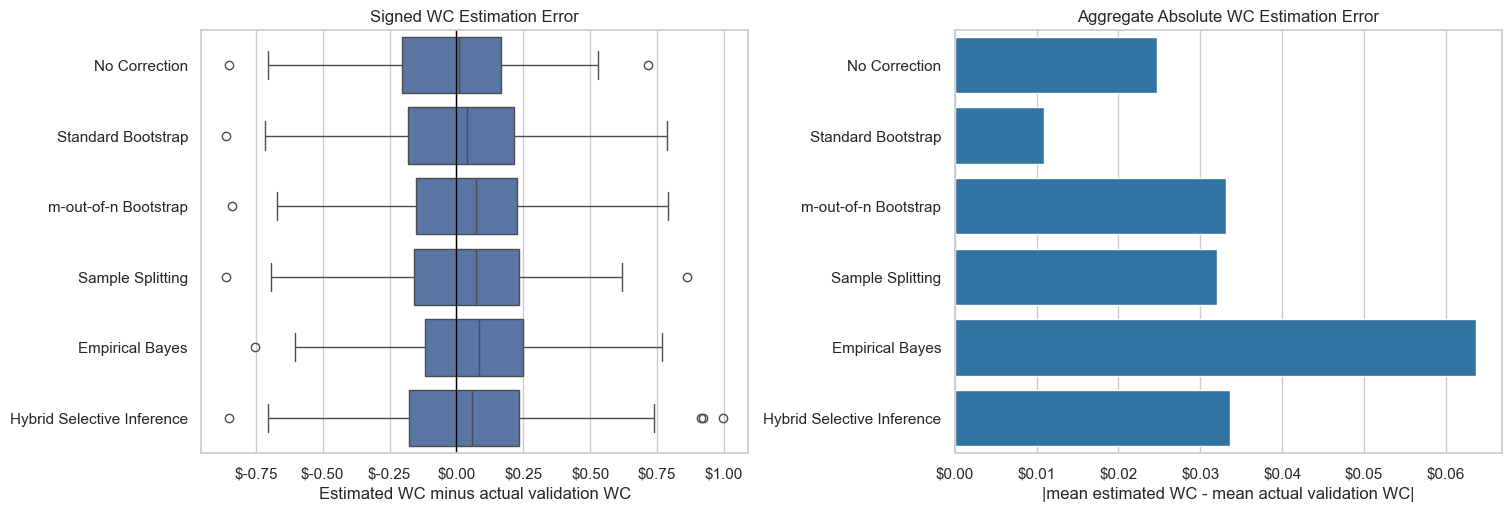

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)

sns.boxplot(
    data=split_corrections,
    y="estimator",
    x="wc_estimation_error",
    order=ESTIMATOR_ORDER,
    ax=axes[0],
)
axes[0].axvline(0, color="black", linewidth=1)
axes[0].set_title("Signed WC Estimation Error")
axes[0].set_xlabel("Estimated WC minus actual validation WC")
axes[0].set_ylabel("")
axes[0].xaxis.set_major_formatter(lambda value, _: f"${value:0.2f}")

sns.barplot(
    data=split_comparison,
    y="estimator",
    x="aggregate_abs_wc_estimation_error",
    order=ESTIMATOR_ORDER,
    ax=axes[1],
    color="tab:blue",
)
axes[1].set_title("Aggregate Absolute WC Estimation Error")
axes[1].set_xlabel("|mean estimated WC - mean actual validation WC|")
axes[1].set_ylabel("")
axes[1].xaxis.set_major_formatter(lambda value, _: f"${value:0.2f}")

plt.show()

## Takeaways

The winner's curse occurs because the selected action is the maximum of noisy mean-spend estimates over the three arms. Each fixed-action mean is unbiased before selection, but the winning estimate is more likely to contain a favorable sampling error. The bias is largest when the leading action values are close relative to their estimation noise, when sample sizes are smaller, and when there are more candidate actions.

The split benchmark compares average bias estimates, not each noisy split as if it were ground truth. For a single split, the held-out validation mean spend is noisy, so per-split absolute errors are dominated by validation noise. The more meaningful validation statistic, following the leaderboard paper, is the aggregate residual between the mean split reference bias and the mean estimated bias.

Estimator-specific overestimation can arise for different reasons. Standard bootstrap can misrepresent the non-smooth max rule near ties. The m-out-of-n bootstrap deliberately adds extra noise by resampling fewer observations, which can overcorrect if the induced switching rate is larger than the target problem requires. Sample splitting evaluates an action chosen from an even smaller internal decision split, so its correction mixes selection-bias reduction with decision-quality loss. Empirical Bayes shrinks the winner toward the common mean of the three action values, which can be too aggressive when the actions have genuinely different values. Hybrid selective inference conditions on the winner event through a truncated-normal approximation and can be sensitive in near-tie splits.

In [ ]:
correction_only = split_comparison.loc[split_comparison["estimator"] != "No Correction"]
best_by_mae = correction_only.sort_values("aggregate_abs_wc_estimation_error").iloc[0]
best_by_rmse = correction_only.sort_values("rmse_wc_estimation_error").iloc[0]
best_by_residual = correction_only.assign(
    abs_residual=lambda data: data["mean_residual_wc_after_correction"].abs()
).sort_values("abs_residual").iloc[0]
no_correction = split_comparison.loc[split_comparison["estimator"] == "No Correction"].iloc[0]

print(f"Full-sample naive winning action: {full_selected_action}")
print(f"Full-sample naive selected value: ${full_naive_value:0.3f}")
print(f"Average actual WC in 50/50 splits: ${split_results['actual_wc'].mean():0.3f}")
print(
    "No-correction mean residual WC in 50/50 splits: "
    f"${no_correction['mean_residual_wc_after_correction']:0.3f}"
)
print(
    "Lowest aggregate absolute WC estimation error among correction methods: "
    f"{best_by_mae['estimator']} (${best_by_mae['aggregate_abs_wc_estimation_error']:0.3f})"
)
print(
    "Lowest split-level WC estimation RMSE among correction methods: "
    f"{best_by_rmse['estimator']} (${best_by_rmse['rmse_wc_estimation_error']:0.3f})"
)
print(
    "Smallest mean residual WC among correction methods: "
    f"{best_by_residual['estimator']} (${best_by_residual['mean_residual_wc_after_correction']:0.3f})"
)